In [ ]:
## Analysis of Mintflow outputs for renal cell carcinoma dataset
## Endothelium subclustering
## Dr Daniyal Jafree, Lotfollahi Group, CellGen Programme, Wellcome Sanger Institute
## Final Version - 20th July 2025

In [1]:
## Set up environment

# local settings, change path if needed
rootdir_inflow = "/nfs/users/nfs_d/dj17/inflow_version3/inflow"  # Change this path if needed

import spatialdata as sd
from spatialdata_io import xenium
import squidpy as sq
from pathlib import Path
import os, sys
import numpy as np
from scipy.sparse import issparse
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import numpy as np
import pandas as pd
import torch
import anndata
import glasbey
from tqdm.autonotebook import tqdm
import gc
import time
import scvi
import os

list_pathstoadd = [
    rootdir_inflow,
    os.path.join(rootdir_inflow, "src"),
    os.path.join(rootdir_inflow, "src", "inflow")
]

for path in list_pathstoadd:
    if(path not in sys.path):
        sys.path.append(path)
        
import inflow

from inflow.cli import parse_config_data_train, parse_config_data_test, parse_config_training, parse_config_model

/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata

In [2]:
print(dir(inflow.cli))

['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'parse_config_data_test', 'parse_config_data_train', 'parse_config_model', 'parse_config_training']


In [3]:
# Set seed
sc.settings.verbosity = 3
sc.settings.seed = 0

# Check if GPU is available
print("GPU Available:", torch.cuda.is_available())
# Check the name of the GPU
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: True
GPU Name: NVIDIA H100 80GB HBM3


In [4]:
## Specify input path / results folder and inspect adata

path_results = \
"/nfs/team361/dj17/inflow_inputsandoutputs/inflow_outputs/version4_lowanneal" # N.B.: this was a run performed on 5001 raw genes, with the anneal max set to 0.1 but window size is still large

config_data_test = parse_config_data_test.parse(
    os.path.join(
        path_results,
        'ConfigFilesCopiedOver',
        'config_data_test_DJ_v2.yml' # this has to be copied over from the config file list and present within the results folder
    )
)

adata = sc.read_h5ad(
    os.path.join(
        path_results,
        'adata_inflowOutput_norm.h5ad' # this is the normalised object, but change if required
    )
)

print(adata)

AnnData object with n_obs × n_vars = 337116 × 5001
    obs: 'batch', 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', '_scvi_batch', '_scvi_labels', 'SCVI_CLUSTERS_KEY', 'cell_area_highlight', 'low_quality_cell_highlight', 'level_1_cell_type', 'level_2_cell_type', 'level_3_cell_type', 'donor', 'inflow_CT', 'inflow_BatchID'
    uns: 'inflow_map_Batchname_to_inflowBatchID', 'inflow_map_CT_to_inflowCT'
    obsm: 'X_scVI', 'X_umap', 'inflow_mu_sin', 'inflow_mu_sout', 'inflow_mu_z', 'inflow_muxbar_int', 'inflow_muxbar_spl', 'inflow_muxint', 'inflow_muxint_before_sc_pp_normalize_total', '

/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [5]:
adata.obsm

AxisArrays with keys: X_scVI, X_umap, inflow_mu_sin, inflow_mu_sout, inflow_mu_z, inflow_muxbar_int, inflow_muxbar_spl, inflow_muxint, inflow_muxint_before_sc_pp_normalize_total, inflow_muxspl, inflow_muxspl_before_sc_pp_normalize_total, spatial

In [6]:
## Setup object with naming and colouring

dict_map_prednames_2_readable = {
    'muxint':'Xint',
    'muxspl':'Xspl',
    'muxbar_int':'Xbar_int',
    'muxbar_spl':'Xbar_spl',
    'mu_sin':'S_in',
    'mu_sout':'S_out',
    'mu_z':'Z',
    'muxint_before_sc_pp_normalize_total':'Xint_without_scppnormalizetotal',
    'muxspl_before_sc_pp_normalize_total':'Xspl_without_scppnormalizetotal'
}

for k in dict_map_prednames_2_readable.keys():
    print("inflow_"+k in adata.obsm.keys())
    
for k in dict_map_prednames_2_readable.keys():
    adata.obsm['inflow_{}'.format(dict_map_prednames_2_readable[k])] = adata.obsm['inflow_'+k] + 0
    del adata.obsm['inflow_'+k]
    print("done for ", k)
    gc.collect()
    
for u in adata.obsm.keys():
    print(u)
    
type(adata.obsm['inflow_Xspl']) # should be numpy.ndarray

#key_celltype = 'level_2_cell_type'
#colpal = glasbey.create_palette(
    #palette_size=len(set(adata.obs[key_celltype]))
#)
#sns.palplot(colpal)

True
True
True
True
True
True
True
True
True
done for  muxint
done for  muxspl
done for  muxbar_int
done for  muxbar_spl
done for  mu_sin
done for  mu_sout
done for  mu_z
done for  muxint_before_sc_pp_normalize_total
done for  muxspl_before_sc_pp_normalize_total
X_scVI
X_umap
spatial
inflow_Xint
inflow_Xspl
inflow_Xbar_int
inflow_Xbar_spl
inflow_S_in
inflow_S_out
inflow_Z
inflow_Xint_without_scppnormalizetotal
inflow_Xspl_without_scppnormalizetotal


numpy.ndarray

In [ ]:
### Predictions are already loaded in in this object, so no need to load them in here

In [7]:
## Endothelial subclustering analysis

adata_blood_vasculature = adata[adata.obs['level_2_cell_type'] == 'Blood vasculature'].copy() # Subset the AnnData object
print(adata_blood_vasculature)

AnnData object with n_obs × n_vars = 44836 × 5001
    obs: 'batch', 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', '_scvi_batch', '_scvi_labels', 'SCVI_CLUSTERS_KEY', 'cell_area_highlight', 'low_quality_cell_highlight', 'level_1_cell_type', 'level_2_cell_type', 'level_3_cell_type', 'donor', 'inflow_CT', 'inflow_BatchID'
    uns: 'inflow_map_Batchname_to_inflowBatchID', 'inflow_map_CT_to_inflowCT'
    obsm: 'X_scVI', 'X_umap', 'spatial', 'inflow_Xint', 'inflow_Xspl', 'inflow_Xbar_int', 'inflow_Xbar_spl', 'inflow_S_in', 'inflow_S_out', 'inflow_Z', 'inflow_Xint_without_scppnormalizet

/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:16)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:17)
Took 36.33748483657837 seconds.


/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


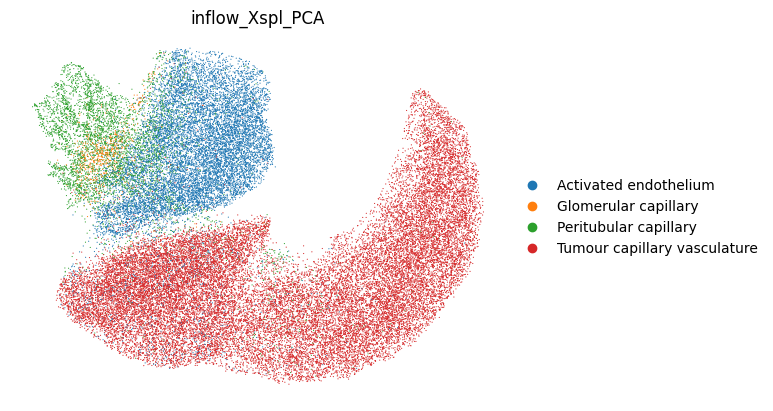

In [8]:
# Perform PCA, nearest neighbors and UMAP based on X spatial for endothelium

t_tic = time.time()
varto_use = 'inflow_Xspl'
from sklearn.decomposition import PCA
pca = PCA(n_components=10)
adata_blood_vasculature.obsm[varto_use+"_PCA"] = pca.fit_transform(adata_blood_vasculature.obsm[varto_use])
sc.pp.neighbors(adata_blood_vasculature, use_rep=varto_use+"_PCA")
sc.tl.umap(adata_blood_vasculature)
sc.pl.umap(
    adata_blood_vasculature,
    color='level_3_cell_type',
    show=False,
    title=varto_use+"_PCA",
    frameon=False
)
print("Took {} seconds.".format(time.time() - t_tic))

running Leiden clustering
    finished: found 13 clusters and added
    'spatial clusters', the cluster labels (adata.obs, categorical) (0:00:18)


/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


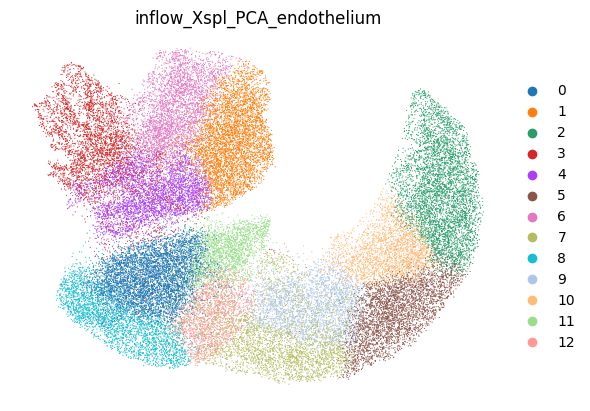

In [9]:
## Identify spatially-defined endothelial subclusters

# Perform Leiden clustering
sc.tl.leiden(adata_blood_vasculature, resolution=0.8, key_added='spatial clusters')

# Plot UMAP with the new annotation
sc.pl.umap(adata_blood_vasculature,
           color=['spatial clusters'],
           title=varto_use + "_PCA_endothelium",
           frameon=False)


/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


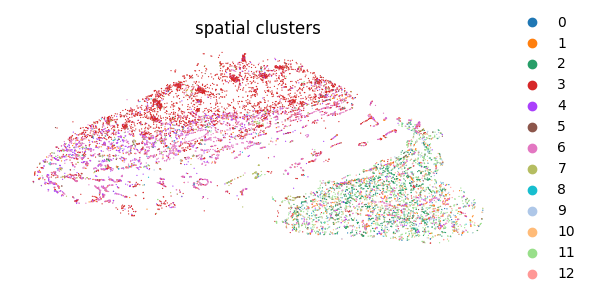

/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


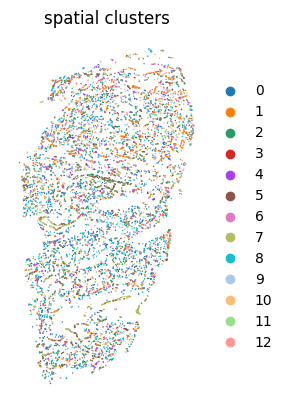

/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


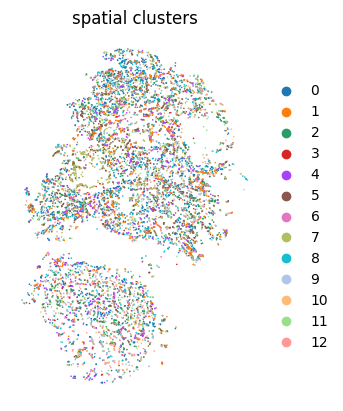

/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


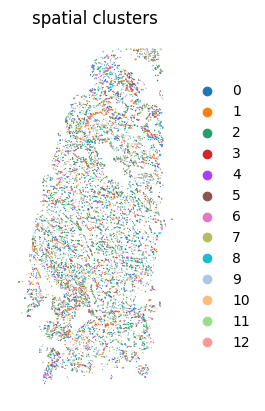

In [10]:
## Spatial plotting of spatially-defined vascular subclusters

batch_id1 = "CV1-KID-0-FO-1"
batch_id2 = "CV1-KID-0-FT-1"
batch_id3 = "CV1-KID-0-FT-2"
batch_id4 = "CV1-KID-0-FT-3"

adata_blood_vasculature_batch1 = adata_blood_vasculature[adata_blood_vasculature.obs['batch'] == batch_id1]
adata_blood_vasculature_batch2 = adata_blood_vasculature[adata_blood_vasculature.obs['batch'] == batch_id2]
adata_blood_vasculature_batch3 = adata_blood_vasculature[adata_blood_vasculature.obs['batch'] == batch_id3]
adata_blood_vasculature_batch4 = adata_blood_vasculature[adata_blood_vasculature.obs['batch'] == batch_id4]

# Plot spatial data
sc.pl.spatial(adata_blood_vasculature_batch1, color='spatial clusters', size=1.5, spot_size=20, frameon=False)
sc.pl.spatial(adata_blood_vasculature_batch2, color='spatial clusters', size=1.5, spot_size=20, frameon=False)
sc.pl.spatial(adata_blood_vasculature_batch3, color='spatial clusters', size=1.5, spot_size=20, frameon=False)
sc.pl.spatial(adata_blood_vasculature_batch4, color='spatial clusters', size=1.5, spot_size=20, frameon=False)


normalizing counts per cell
    finished (0:00:00)
ranking genes


/nfs/users/nfs_d/dj17/Daniyal_training/DJ_VENV/lib/python3.11/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:23)


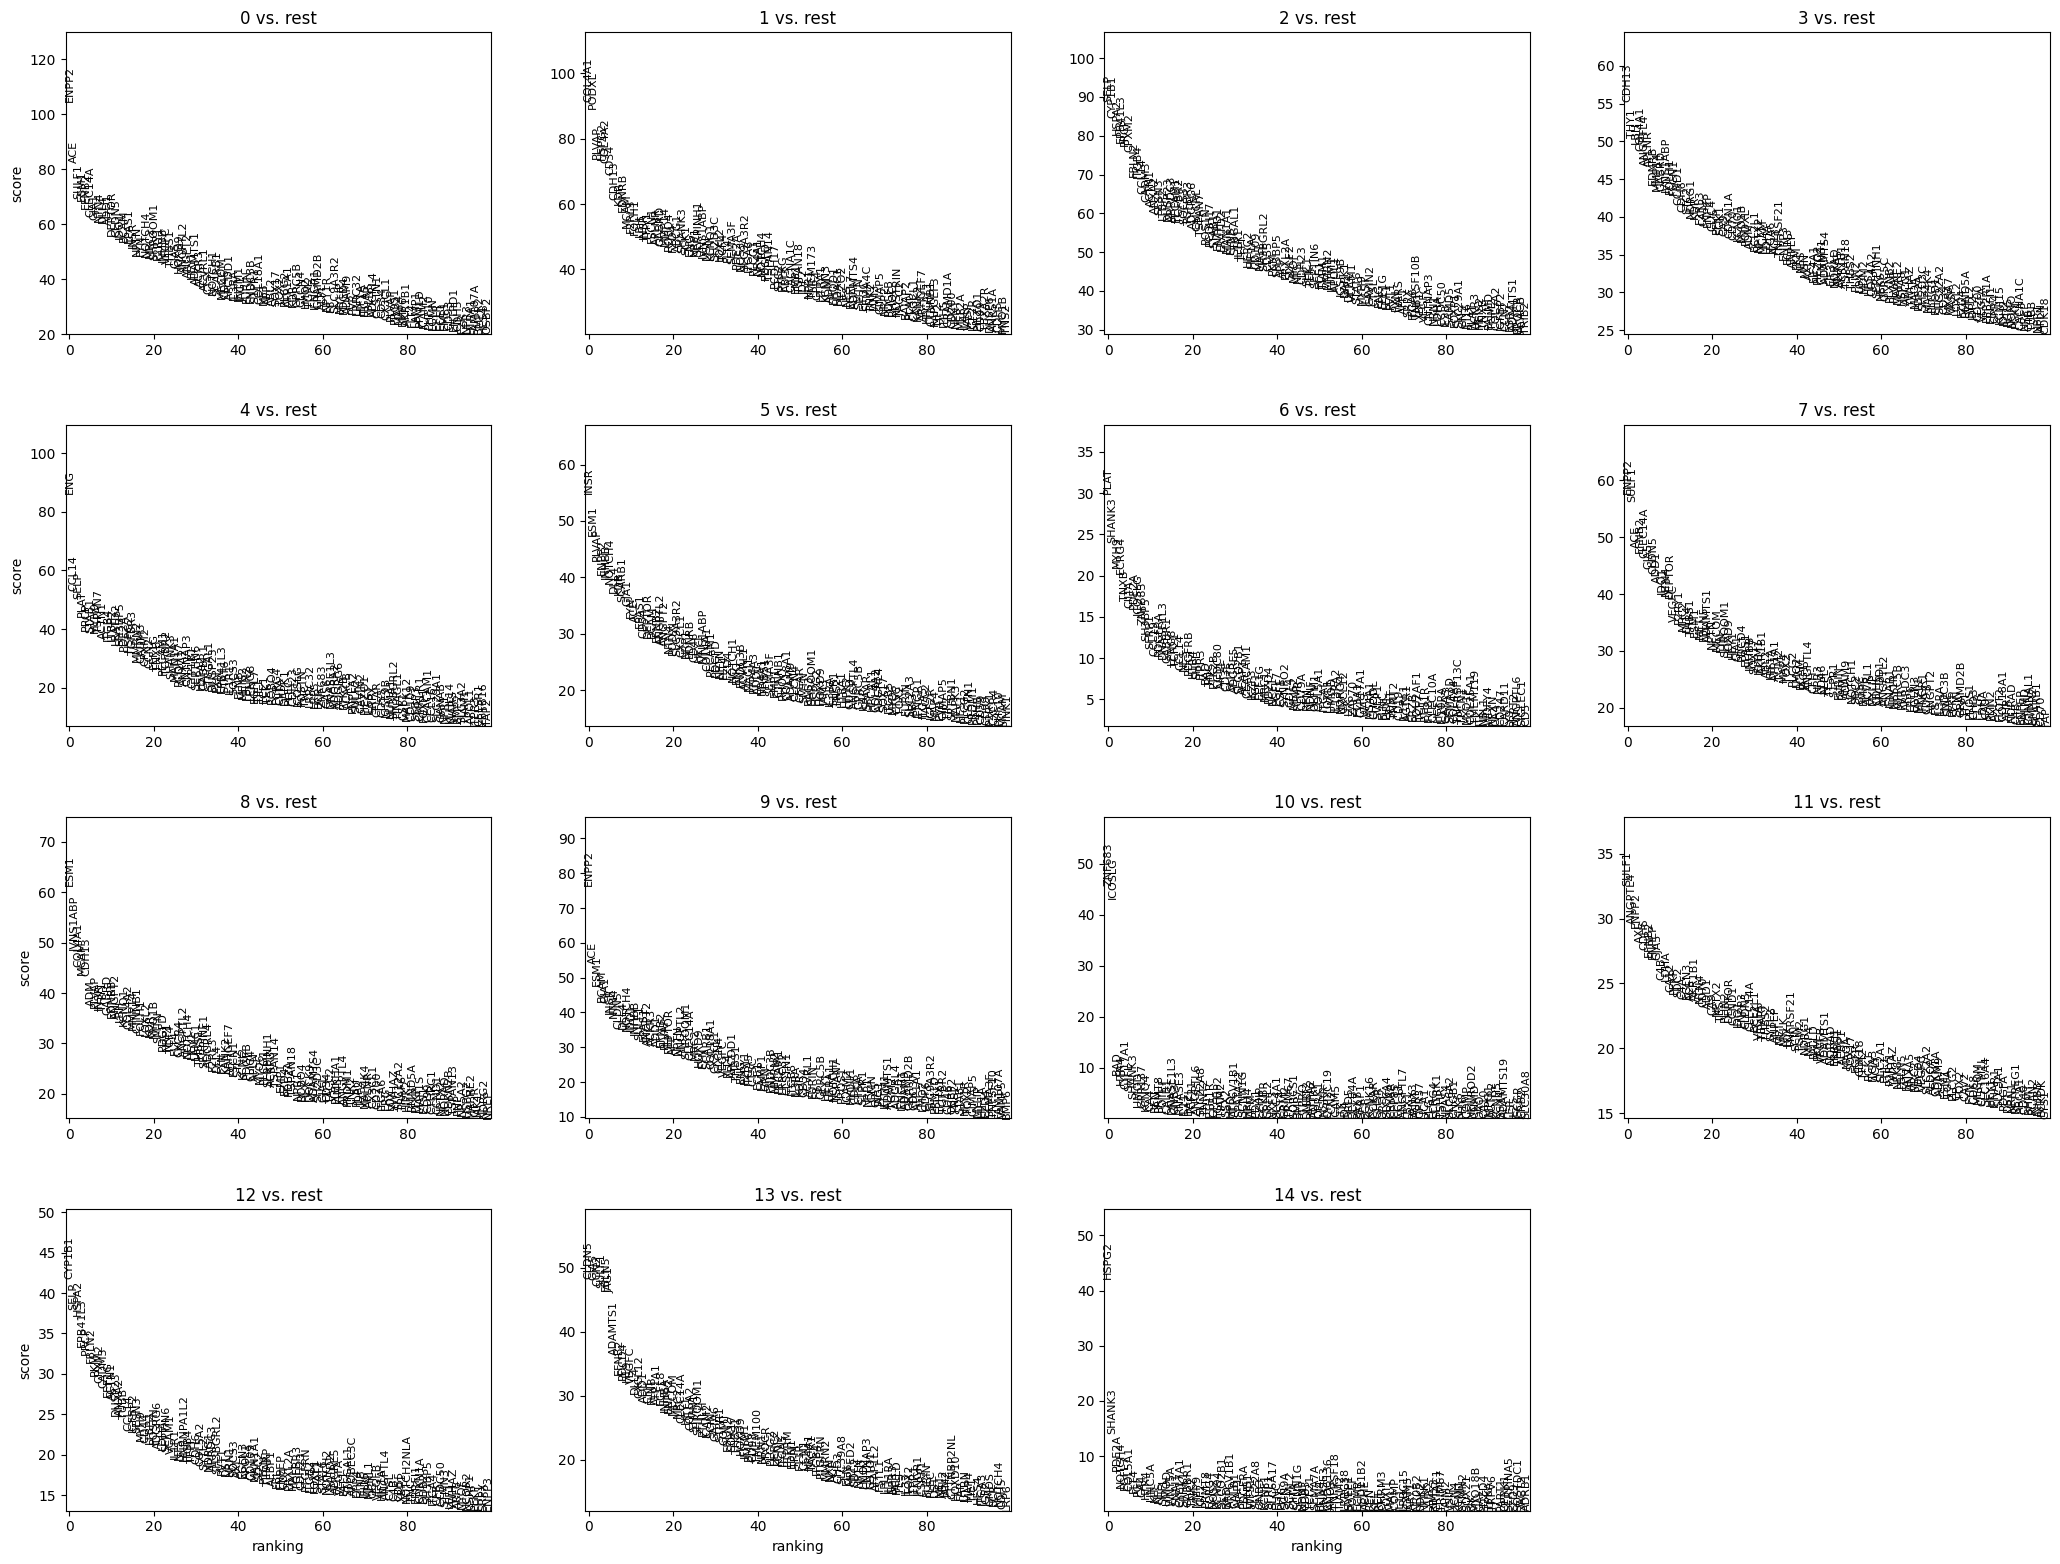

Top genes in 0:
['ENPP2' 'ACE' 'SULF1' 'ESM1' 'EFNB2' 'CLEC14A' 'GJA1' 'NTN4' 'DLL4'
 'ADD1' 'DEPTOR' 'CLDN5' 'IDO1' 'BCAM' 'EPAS1' 'INSR' 'NPTN' 'FYN'
 'NOTCH4' 'MRC2' 'SHROOM1' 'P2RY1' 'INHBB' 'VEGFC' 'THBS1' 'GJA5' 'HOXD9'
 'ANGPTL2' 'ANGPT2' 'HEY1' 'ADAMTS1' 'ACKR3' 'ACVRL1' 'CTSC' 'NOTCH1'
 'SCARB1' 'MECOM' 'CD46' 'APCDD1' 'IL3RA' 'IFITM1' 'JAG1' 'FURIN' 'FNDC3B'
 'S1PR1' 'COL18A1' 'MET' 'APP' 'ABL2' 'SOX17' 'TOX2' 'PLCG2' 'ATP1A1'
 'KDR' 'GPRC5B' 'CLCN4' 'LMO2' 'TGM2' 'IFNGR1' 'GRAMD2B' 'ALPL' 'NPY1R'
 'F8' 'SLC9A3R2' 'MYLIP' 'PDCD4' 'ADAM9' 'PVR' 'LRRC32' 'HIF1A' 'ITGA5'
 'FBLN5' 'ADGRL4' 'CLSTN1' 'CD34' 'CX3CL1' 'PLVAP' 'PROS1' 'MAP4' 'BMP6'
 'AKR1B1' 'FLT4' 'LAMP1' 'PPM1D' 'ICAM2' 'PHF10' 'LGMN' 'F11R' 'ECE1'
 'EMP1' 'CD93' 'ENTPD1' 'CDH5' 'F2R' 'NPR3' 'HTRA1' 'FAM107A' 'BMPR2'
 'HES4' 'OSBP2']
Top genes in 1:
['COL4A1' 'PODXL' 'PLVAP' 'HSPG2' 'COL4A2' 'CD34' 'CDH13' 'KDR' 'EDNRB'
 'MCAM' 'F2RL3' 'FOLH1' 'LBH' 'INSR' 'THY1' 'FSCN1' 'APLNR' 'GABRD'
 'MMP14' 'ROBO4' 'FZD4' 'ABCG

In [51]:
## Runs preliminary differential expression tests for endothelium

# Normalize total counts per cell (if not already done)
sc.pp.normalize_total(adata_blood_vasculature, target_sum=1e4)
sc.pp.log1p(adata_blood_vasculature)

# Now run the differential expression analysis using these counts
sc.tl.rank_genes_groups(adata_blood_vasculature, groupby='spatial clusters', method='wilcoxon')
sc.pl.rank_genes_groups(adata_blood_vasculature, n_genes=100, sharey=False)

# Optionally, view the top genes per cluster
result = adata_blood_vasculature.uns['rank_genes_groups']
groups = result['names'].dtype.names  # cluster names
for group in groups:
    print(f"Top genes in {group}:")
    print(result['names'][group][:100])